In [19]:
import os
import sys
import numpy as np
import xarray as xr
import geopandas as gpd
import shapely.vectorized as sv

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec

import warnings
warnings.filterwarnings('ignore')

In [20]:
dir_base = os.path.join('/','media','arturo','T9','Data','Italy','Satellite','2_MEV','uncorrected')
veneto_dir = os.path.join('/','media','arturo','T9','Data','shapes','Europa','Italy')

In [21]:
# lon_min, lon_max, lat_min, lat_max, area = 6.5, 19, 36.5, 48, 'ITALY'
# lon_min, lon_max, lat_min, lat_max, area = 10.5, 13.5, 44.5, 47, 'VENETO'
lon_min, lon_max, lat_min, lat_max, area = 11, 12.5, 45, 46, 'PADOVA'

In [22]:
if area == 'PADOVA':
    GEOMETRY = gpd.read_file(os.path.join('..','..', 'geometry','Padova.geojson'))
elif area == 'VENETO':
    GEOMETRY = gpd.read_file(os.path.join('..','..', 'geometry','Veneto.geojson'))
elif area == 'ITALY':
    GEOMETRY = gpd.read_file(os.path.join('..','..', 'geometry','Italy_simple.geojson'))
else:
    sys.exit("Area not recognized. Please choose 'VENETO' or 'ITALY'.")

GEOMETRY_union = GEOMETRY.unary_union # ONLY FOR VENETO

In [23]:
inputfile = os.path.join(dir_base,'PADOVA_DOWN_IMERG_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson_inside.nc')
DATA = xr.open_dataset(inputfile)
lon2d_CM, lat2d_CM = np.meshgrid(DATA.lon.values, DATA.lat.values)

CMORPH_mev = DATA.Mev_s.values
CMORPH_med = DATA.Mev_d.values

In [24]:
Mev_cmap = plt.cm.Spectral_r
Mev_norm = None

Text(0.0, 1.0, '(d) Downscaled - Raw')

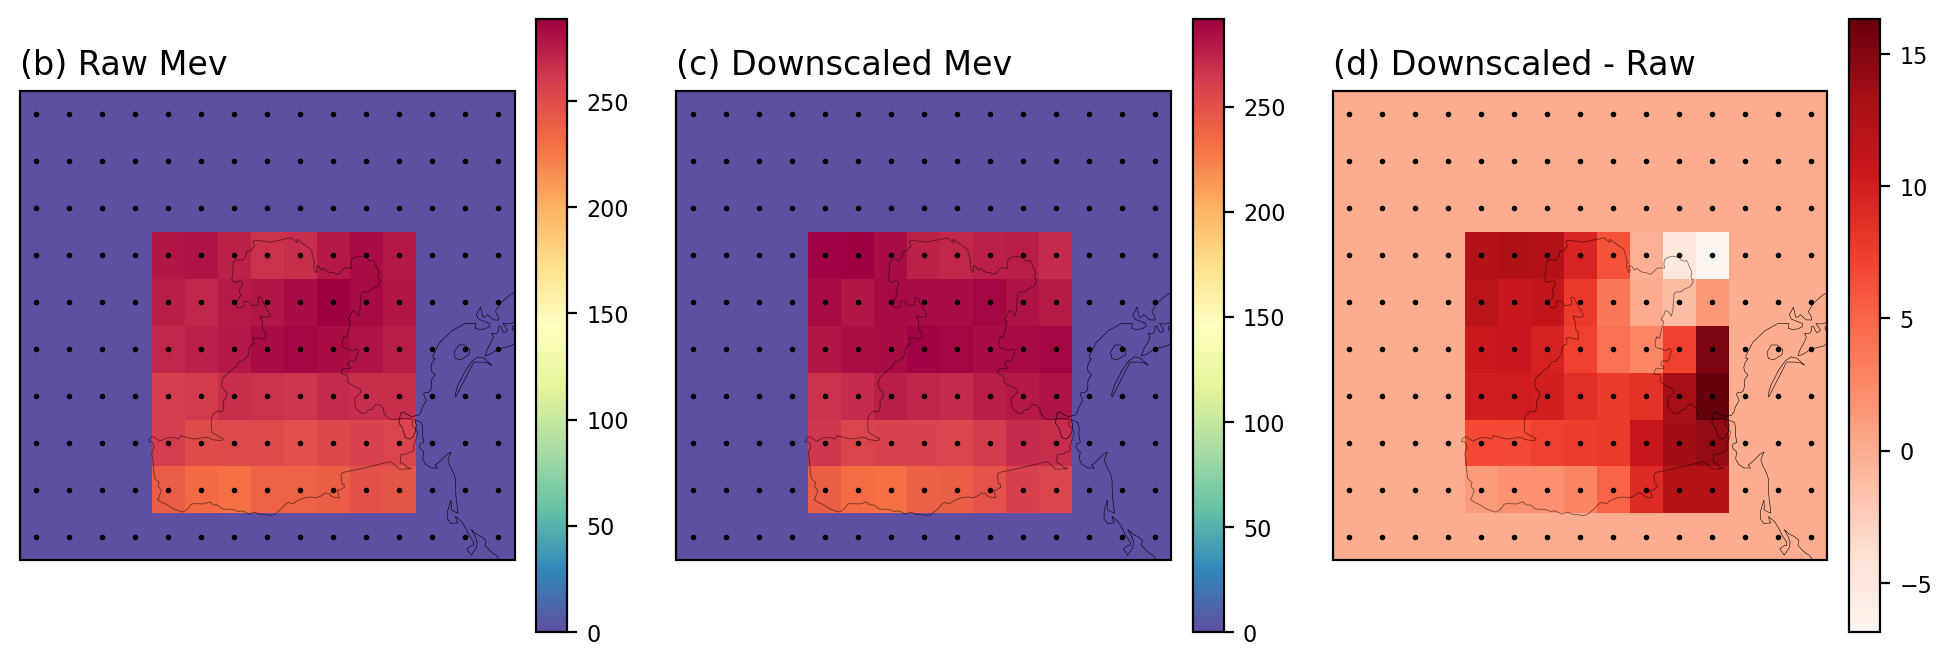

In [25]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(12,4),dpi=200)
gs = gridspec.GridSpec(1,3)

# ====================================================================================================================
ax1 = plt.subplot(gs[0, 0], projection = proj)
ax1.coastlines(linewidth=0.2)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
GEOMETRY.plot(facecolor='None', edgecolor='k', ax=ax1, linewidth=0.3, zorder=21, alpha=0.5)
a1 = ax1.pcolormesh(lon2d_CM, lat2d_CM, CMORPH_mev[3,:,:], norm=Mev_norm, cmap=Mev_cmap)
ax1.scatter(lon2d_CM.flatten(), lat2d_CM.flatten(), s=1, c='k')
cbar = plt.colorbar(a1, ax=ax1, fraction=0.056, pad=0.04)
cbar.ax.tick_params(labelsize=8)
ax1.set_title('(b) Raw Mev', fontsize=12, loc='left')

# ====================================================================================================================
ax1 = plt.subplot(gs[0, 1], projection = proj)
ax1.coastlines(linewidth=0.2)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
GEOMETRY.plot(facecolor='None', edgecolor='k', ax=ax1, linewidth=0.3, zorder=21, alpha=0.5)
a1 = ax1.pcolormesh(lon2d_CM, lat2d_CM, CMORPH_med[3,:,:], norm=Mev_norm, cmap=Mev_cmap)
ax1.scatter(lon2d_CM.flatten(), lat2d_CM.flatten(), s=1, c='k')
cbar = plt.colorbar(a1, ax=ax1, fraction=0.056, pad=0.04)
cbar.ax.tick_params(labelsize=8)
ax1.set_title('(c) Downscaled Mev', fontsize=12, loc='left')

# ====================================================================================================================
ax1 = plt.subplot(gs[0, 2], projection = proj)
ax1.coastlines(linewidth=0.2)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
GEOMETRY.plot(facecolor='None', edgecolor='k', ax=ax1, linewidth=0.3, zorder=21, alpha=0.5)
a1 = ax1.pcolormesh(lon2d_CM, lat2d_CM, CMORPH_med[3,:,:]-CMORPH_mev[3,:,:], norm=None, cmap='Reds')
ax1.scatter(lon2d_CM, lat2d_CM, s=1, c='k')
cbar = plt.colorbar(a1, ax=ax1, fraction=0.056, pad=0.04)
cbar.ax.tick_params(labelsize=8)
ax1.set_title('(d) Downscaled - Raw', fontsize=12, loc='left')

# ====================================================================================================================
# plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.95, wspace=-0.05, hspace=0.08)

In [26]:
lon2d_CM.shape

(15, 15)

In [27]:
np.shape(CMORPH_mev[3,:,:])

(15, 15)